In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('amazon_laptop_price_dataset.csv')
df

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,1092.04
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,1934.84
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,758.86
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,1430.88
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,1457.77
...,...,...,...,...,...,...,...,...
995,Dell,Intel i5,8,1024,Windows 10,NVIDIA GTX 1650,3.7,1700.53
996,Apple,AMD Ryzen 5,8,256,Windows 10,NVIDIA GTX 1650,3.1,1534.86
997,Apple,AMD Ryzen 5,32,512,Windows 10,Integrated,3.6,2101.13
998,Dell,AMD Ryzen 5,32,128,Windows 11,Integrated,3.3,1289.01


In [3]:
df['Price_USD']=pd.to_numeric(df['Price_USD'], errors='coerce')
df['Price_IND']=df['Price_USD']*90

In [4]:
df.describe()

,RAM_GB,Storage_GB,Rating,Price_USD,Price_IND
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,15.252000,460.032000,4.030300,1462.197300,131597.757000
std,10.693683,336.083691,0.580852,479.697515,43172.776309
min,4.000000,128.000000,3.000000,404.830000,36434.700000
25%,8.000000,128.000000,3.500000,1101.552500,99139.725000
50%,16.000000,256.000000,4.100000,1421.705000,127953.450000
75%,32.000000,512.000000,4.500000,1793.382500,161404.425000
max,32.000000,1024.000000,5.000000,2896.850000,260716.500000


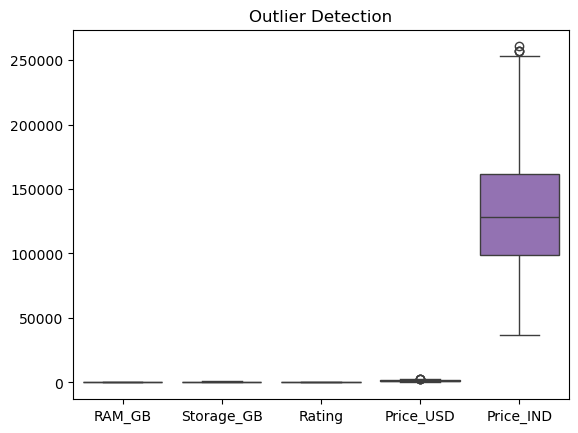

In [5]:
sns.boxplot(data=df)
plt.title("Outlier Detection")
plt.show()

In [6]:
df

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD,Price_IND
0,MSI,AMD Ryzen 3,4,512,macOS,AMD Radeon,4.2,1092.04,98283.6
1,Lenovo,Intel i7,32,128,macOS,NVIDIA GTX 1650,3.1,1934.84,174135.6
2,Asus,AMD Ryzen 7,8,256,Windows 10,Integrated,3.6,758.86,68297.4
3,Dell,Intel i7,16,512,Windows 11,AMD Radeon,3.6,1430.88,128779.2
4,MSI,AMD Ryzen 7,8,512,Windows 11,NVIDIA RTX 3050,3.8,1457.77,131199.3
...,...,...,...,...,...,...,...,...,...
995,Dell,Intel i5,8,1024,Windows 10,NVIDIA GTX 1650,3.7,1700.53,153047.7
996,Apple,AMD Ryzen 5,8,256,Windows 10,NVIDIA GTX 1650,3.1,1534.86,138137.4
997,Apple,AMD Ryzen 5,32,512,Windows 10,Integrated,3.6,2101.13,189101.7
998,Dell,AMD Ryzen 5,32,128,Windows 11,Integrated,3.3,1289.01,116010.9


In [7]:
# Q1 = df[['RAM_GB','Storage_GB','Rating','Price_USD','Price_IND']].quantile(0.25)
# Q3 = df[['RAM_GB','Storage_GB','Rating','Price_USD','Price_IND']].quantile(0.75)

# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# outliers = ((df[['RAM_GB','Storage_GB','Rating','Price_USD','Price_IND']] 
#              < lower_bound) | 
#             (df[['RAM_GB','Storage_GB','Rating','Price_USD','Price_IND']] 
#              > upper_bound))

# df[outliers.any(axis=1)]

In [8]:
# REMOVE OUTLIERS

# df=df['Price']>=lower_bound

In [9]:
df['Operating_System'].value_counts()

Operating_System
Windows 11    345
macOS         329
Windows 10    326
Name: count, dtype: int64

In [10]:
df['GPU'].value_counts()

GPU
Integrated         279
AMD Radeon         268
NVIDIA RTX 3050    246
NVIDIA GTX 1650    207
Name: count, dtype: int64

In [11]:
df['Processor'].value_counts()

Processor
AMD Ryzen 7    183
Intel i5       176
AMD Ryzen 5    173
Intel i7       160
AMD Ryzen 3    158
Intel i3       150
Name: count, dtype: int64

In [12]:
from sklearn.preprocessing import OneHotEncoder

encoder=OneHotEncoder(sparse_output=False)

brand_encoded = encoder.fit_transform(df[['Brand']])
brand_encoded

array([[0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(1000, 7))

In [13]:
brand_df = pd.DataFrame(
    brand_encoded, 
    columns=encoder.get_feature_names_out(['Brand'])
)
df=pd.concat([df,brand_df],axis=1)

In [14]:
df.sample(20)

,Brand,Processor,RAM_GB,Storage_GB,Operating_System,GPU,Rating,Price_USD,Price_IND,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
203,HP,AMD Ryzen 3,16,512,Windows 11,AMD Radeon,3.3,1173.91,105651.9,0.0,0.0,0.0,0.0,1.0,0.0,0.0
163,Asus,Intel i5,8,128,Windows 10,NVIDIA GTX 1650,3.5,938.60,84474.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
465,Acer,Intel i3,32,1024,macOS,Integrated,4.4,2192.20,197298.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
323,Asus,Intel i5,16,256,macOS,Integrated,4.9,1352.72,121744.8,0.0,0.0,1.0,0.0,0.0,0.0,0.0
22,Apple,Intel i7,4,256,Windows 10,Integrated,3.2,1288.77,115989.3,0.0,1.0,0.0,0.0,0.0,0.0,0.0
171,HP,AMD Ryzen 3,16,1024,macOS,NVIDIA RTX 3050,4.7,2035.27,183174.3,0.0,0.0,0.0,0.0,1.0,0.0,0.0
90,HP,Intel i3,8,512,macOS,Integrated,4.7,1025.68,92311.2,0.0,0.0,0.0,0.0,1.0,0.0,0.0
652,Asus,AMD Ryzen 3,8,512,Windows 11,AMD Radeon,3.7,901.46,81131.4,0.0,0.0,1.0,0.0,0.0,0.0,0.0
532,Apple,AMD Ryzen 5,16,256,Windows 11,NVIDIA RTX 3050,3.8,1712.88,154159.2,0.0,1.0,0.0,0.0,0.0,0.0,0.0
656,Apple,AMD Ryzen 7,8,128,Windows 11,AMD Radeon,4.5,1317.29,118556.1,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# split data into x and y

y = df['Price_IND']
X = df[[col for col in df.columns if col.startswith('Brand_')]]

In [16]:
# split data into training and testing 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# fit data into linear regression model

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
 df[[col for col in df.columns if col.startswith('Brand_')]]

,Brand_Acer,Brand_Apple,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo,Brand_MSI
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,0.0,0.0,0.0
996,0.0,1.0,0.0,0.0,0.0,0.0,0.0
997,0.0,1.0,0.0,0.0,0.0,0.0,0.0
998,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [19]:
# caculate the y_pred predicted value
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MSE: 1748328943.1920922
RMSE: 41813.02360738927
R2 Score: 0.11346484730805584


In [21]:

coefficients = pd.DataFrame({
    'Brand': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("Intercept (Baseline - Acer):", model.intercept_)

          Brand   Coefficient
0    Brand_Acer -10150.331680
1   Brand_Apple  30268.605162
2    Brand_Asus  -3585.533914
3    Brand_Dell  -3785.120731
4      Brand_HP  -6796.317735
5  Brand_Lenovo  -3213.443867
6     Brand_MSI  -2737.857235
Intercept (Baseline - Acer): 131012.74483805579
